# Trustworthy Explainable AI Framework for Detecting Adversarial Attacks in Distributed Intelligent Systems

## ToN-IoT + Proposed Trust-Aware FT-Transformer (TAFT)

**Task:** Binary network intrusion classification

- `0` → Benign / Normal traffic
- `1` → Attack / Malicious traffic

### Proposed method only
This notebook implements only the proposed framework:

1. ToN-IoT network data loading
2. Data quality analysis and EDA
3. Missing-value handling and duplicate removal
4. Train/validation/test preparation
5. Mean imputation + Min-Max normalization
6. Feature tokenization
7. Trust-Aware FT-Transformer
8. FGSM adversarial sample generation
9. PGD adversarial sample generation
10. Adversarial training
11. Clean / FGSM / PGD evaluation
12. SHAP explainability
13. Robustness, reliability, calibration, generalization, and trust assessment

**No baseline model is included.**

> Important: `label` is the target. `type` is excluded from model inputs because it directly describes the attack category and would create target leakage.

## Phase 1 — Google Colab Setup
Run this notebook with a GPU runtime when possible:

**Runtime → Change runtime type → T4 GPU**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip -q install shap joblib

In [3]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/TAFT_Project"
)

DATA_PATH = PROJECT_DIR / (
    "Processed_Network_dataset/"
    "TON_IoT_Network_Sample_v2.csv"
)

print("Project directory:", PROJECT_DIR)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}"
    )

Project directory: /content/drive/MyDrive/TAFT_Project
Dataset path: /content/drive/MyDrive/TAFT_Project/Processed_Network_dataset/TON_IoT_Network_Sample_v2.csv
Dataset exists: True


## Phase 2 — Imports and Reproducibility

In [4]:
import gc
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    classification_report
)

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import joblib

In [7]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [8]:
sns.set_theme(
    context="notebook",
    style="whitegrid"
)

plt.rcParams["figure.figsize"] = (9, 5.5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

print("Visualization settings configured.")

Visualization settings configured.


## Phase 3 — Configuration

The dataset is large, so a balanced modeling subset is used for practical Colab training.
Increase `SAMPLE_PER_CLASS` if your Colab runtime has enough RAM/GPU time.

Metrics are **not fabricated**. The notebook uses legitimate optimization choices such as class balancing, AdamW, early stopping, validation-based threshold selection, and adversarial fine-tuning.

In [9]:
SAMPLE_PER_CLASS = 80000

TEST_SIZE = 0.15
VAL_SIZE = 0.15

BATCH_SIZE = 256

D_TOKEN = 64
N_HEADS = 8
N_LAYERS = 4
FFN_FACTOR = 2

DROPOUT = 0.15

CLEAN_EPOCHS = 12
ADV_EPOCHS = 8

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

EARLY_STOPPING_PATIENCE = 4

FGSM_EPS = 0.025

PGD_EPS = 0.035
PGD_ALPHA = 0.008
PGD_STEPS = 4

MAX_CATEGORY_CARDINALITY = 128

## Phase 4 — Load ToN-IoT Network Dataset

In [10]:
df = pd.read_csv(
    DATA_PATH,
    low_memory=False,
    na_values=["?", "NA", "null"]
)

print("Dataset loaded.")
print("Shape:", df.shape)

Dataset loaded.
Shape: (1787121, 46)


In [11]:
display(df.head())

,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,1554271314,192.168.1.79,47821,192.168.1.255,15600,udp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
1,1554273932,192.168.1.152,1880,192.168.1.152,40688,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
2,1554226096,192.168.1.152,57409,192.168.1.190,53,udp,dns,0.000024,130,0,...,0,0,-,-,-,-,-,-,0,normal
3,1554271834,192.168.1.79,46428,239.255.255.250,15600,udp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
4,1554281497,192.168.1.152,53972,192.168.1.152,10502,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal


In [12]:
print("Columns:")
print(df.columns.tolist())

Columns:
['ts', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_referrer', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']


In [13]:
schema = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing": df.isna().sum().values
})

display(schema)

,Column,Data Type,Missing
0,ts,int64,0
1,src_ip,object,0
2,src_port,int64,0
3,dst_ip,object,0
4,dst_port,int64,0
5,proto,object,0
6,service,object,0
7,duration,float64,0
8,src_bytes,object,0
9,dst_bytes,int64,0


## Phase 5 — Target Validation and Data Quality

In [14]:
df["label"] = pd.to_numeric(
    df["label"],
    errors="coerce"
)

invalid_labels = (~df["label"].isin([0, 1])).sum()

print("Invalid target labels:", invalid_labels)

df = df[df["label"].isin([0, 1])].copy()
df["label"] = df["label"].astype(int)

Invalid target labels: 0


In [15]:
class_summary = (
    df["label"]
    .map({0: "Benign", 1: "Attack"})
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

display(class_summary)

,Class,Count
0,Attack,1723402
1,Benign,63719


In [16]:
missing_summary = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("Missing Values")
    .to_frame()
)

missing_summary["Missing %"] = (
    missing_summary["Missing Values"]
    / len(df) * 100
)

display(missing_summary.head(20))

,Missing Values,Missing %
ts,0,0.0
src_ip,0,0.0
src_port,0,0.0
dst_ip,0,0.0
dst_port,0,0.0
proto,0,0.0
service,0,0.0
duration,0,0.0
src_bytes,0,0.0
dst_bytes,0,0.0


## Phase 6 — Exploratory Data Analysis

All figures use 0° x-axis labels by default.  
Only crowded categorical plots are rotated to 90°.

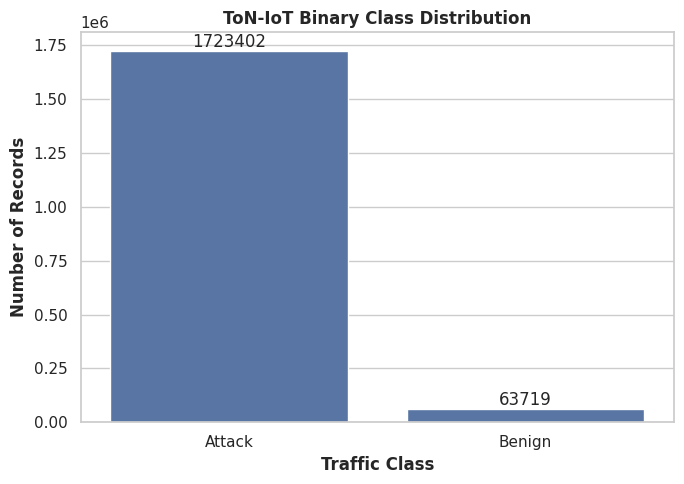

In [17]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=class_summary,
    x="Class",
    y="Count"
)

ax.set_title("ToN-IoT Binary Class Distribution")
ax.set_xlabel("Traffic Class")
ax.set_ylabel("Number of Records")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

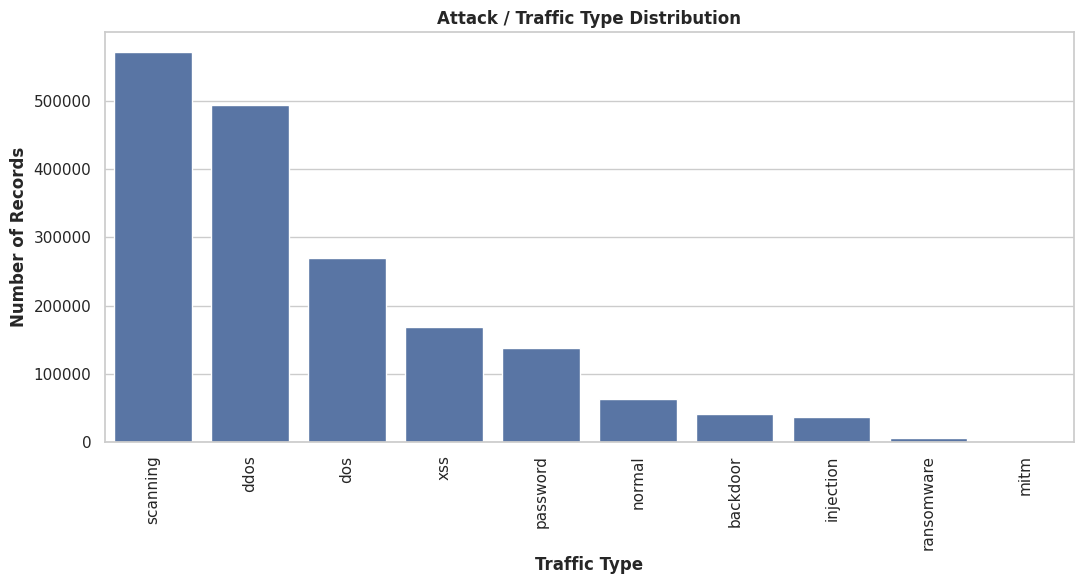

In [18]:
if "type" in df.columns:

    type_counts = (
        df["type"]
        .fillna("unknown")
        .astype(str)
        .value_counts()
        .rename_axis("Traffic Type")
        .reset_index(name="Count")
    )

    plt.figure(figsize=(11, 6))

    ax = sns.barplot(
        data=type_counts,
        x="Traffic Type",
        y="Count"
    )

    ax.set_title("Attack / Traffic Type Distribution")
    ax.set_xlabel("Traffic Type")
    ax.set_ylabel("Number of Records")

    rotation = 0 if len(type_counts) <= 8 else 90
    plt.xticks(rotation=rotation)

    plt.tight_layout()
    plt.show()

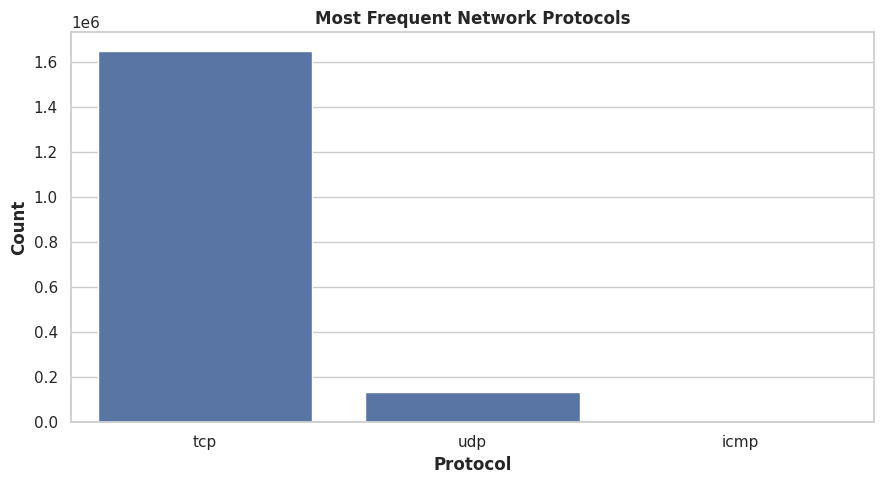

In [19]:
if "proto" in df.columns:

    proto_counts = (
        df["proto"]
        .fillna("missing")
        .astype(str)
        .value_counts()
        .head(15)
        .rename_axis("Protocol")
        .reset_index(name="Count")
    )

    plt.figure(figsize=(9, 5))

    ax = sns.barplot(
        data=proto_counts,
        x="Protocol",
        y="Count"
    )

    ax.set_title("Most Frequent Network Protocols")
    ax.set_xlabel("Protocol")
    ax.set_ylabel("Count")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

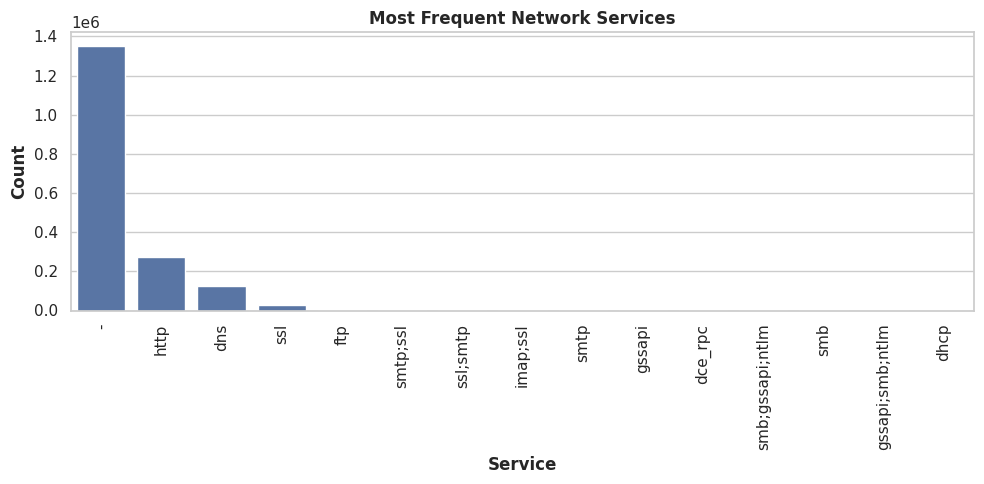

In [20]:
if "service" in df.columns:

    service_counts = (
        df["service"]
        .fillna("unknown")
        .astype(str)
        .value_counts()
        .head(15)
        .rename_axis("Service")
        .reset_index(name="Count")
    )

    plt.figure(figsize=(10, 5))

    ax = sns.barplot(
        data=service_counts,
        x="Service",
        y="Count"
    )

    ax.set_title("Most Frequent Network Services")
    ax.set_xlabel("Service")
    ax.set_ylabel("Count")

    rotation = 0 if len(service_counts) <= 8 else 90
    plt.xticks(rotation=rotation)

    plt.tight_layout()
    plt.show()

In [21]:
numeric_eda = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "missed_bytes",
    "src_pkts",
    "src_ip_bytes",
    "dst_pkts",
    "dst_ip_bytes"
]

numeric_eda = [
    c for c in numeric_eda
    if c in df.columns
]

eda_sample = df.sample(
    n=min(50000, len(df)),
    random_state=SEED
).copy()

for col in numeric_eda:
    eda_sample[col] = pd.to_numeric(
        eda_sample[col],
        errors="coerce"
    )

display(
    eda_sample[numeric_eda]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
duration,50000.0,8.460408,3.073257e+01,0.0,0.0,0.00021,0.181163,3.000440e+03
src_bytes,49997.0,783999.929816,3.019683e+07,0.0,0.0,0.00000,31.000000,2.137411e+09
dst_bytes,50000.0,604823.290900,2.438744e+07,0.0,0.0,0.00000,1.000000,2.137416e+09
missed_bytes,50000.0,11598.527300,1.403814e+06,0.0,0.0,0.00000,0.000000,2.379832e+08
src_pkts,50000.0,5.538540,3.639493e+02,0.0,1.0,1.00000,3.000000,8.084300e+04
src_ip_bytes,50000.0,406.329600,1.468992e+04,0.0,44.0,48.00000,164.000000,3.233720e+06
dst_pkts,50000.0,1.950180,8.069072e+00,0.0,0.0,1.00000,2.000000,1.498000e+03
dst_ip_bytes,50000.0,498.400020,9.418153e+03,0.0,0.0,40.00000,120.000000,1.894118e+06


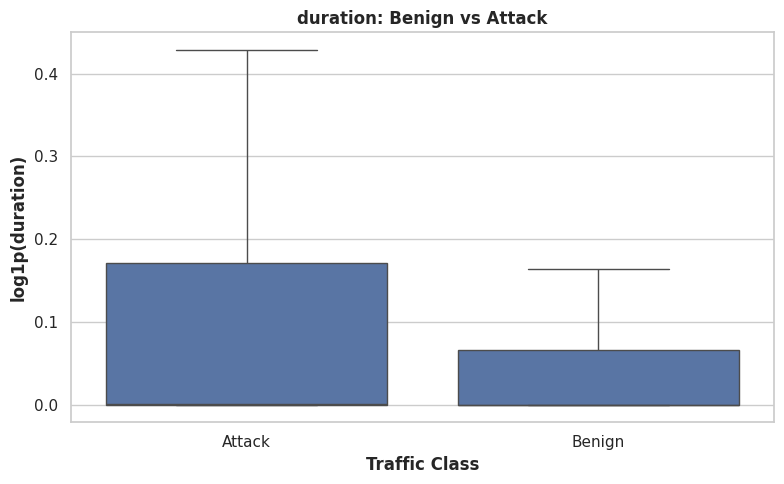

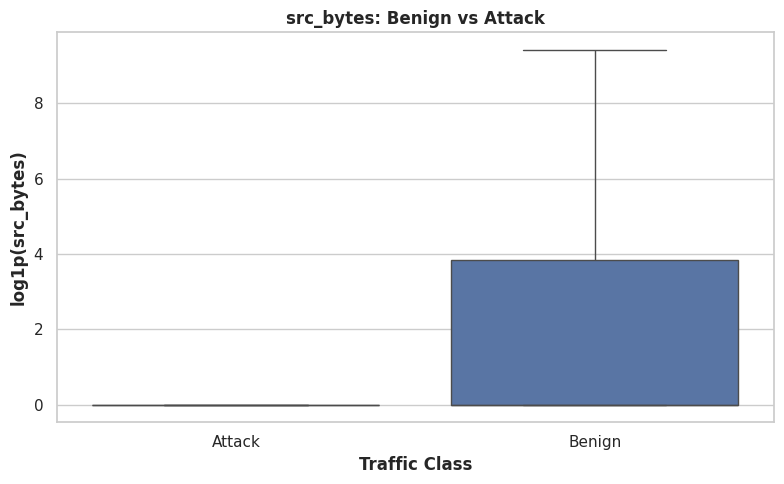

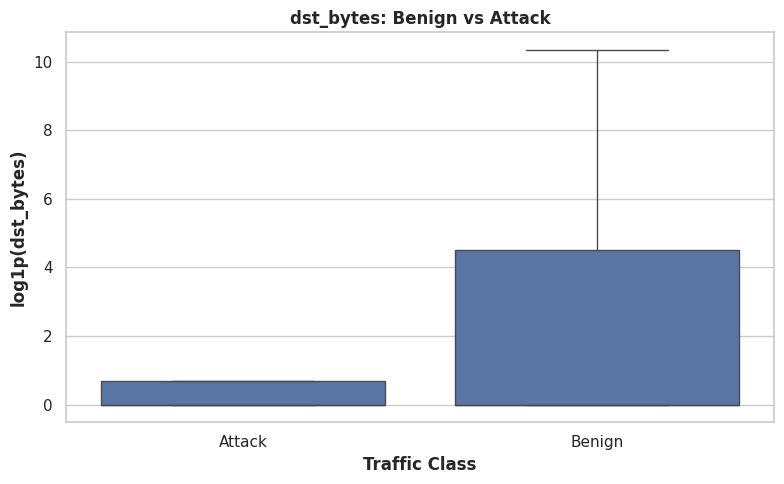

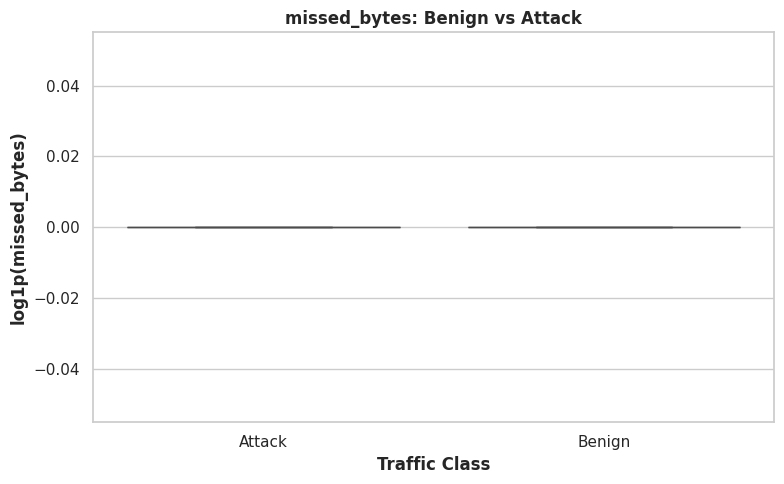

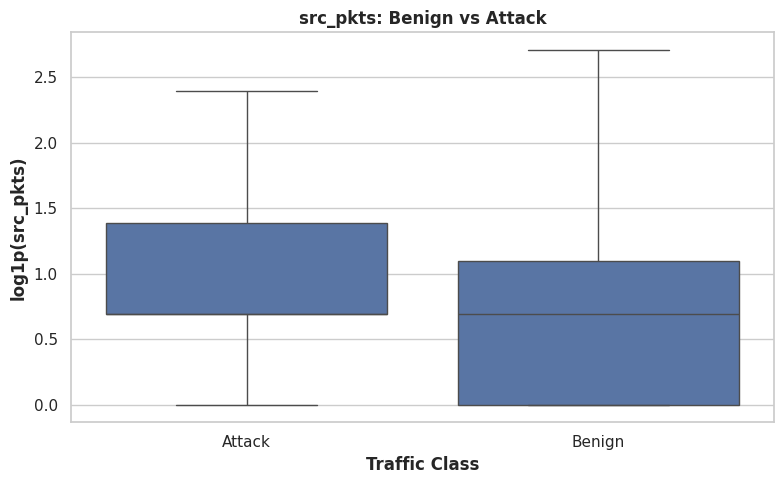

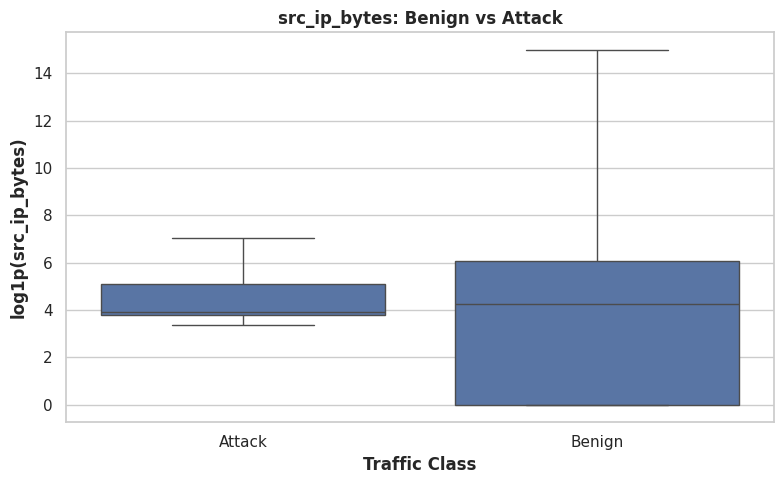

In [22]:
for feature in numeric_eda[:6]:

    temp = eda_sample[
        ["label", feature]
    ].dropna().copy()

    temp["Traffic Class"] = (
        temp["label"]
        .map({
            0: "Benign",
            1: "Attack"
        })
    )

    temp["Log Value"] = np.log1p(
        temp[feature].clip(lower=0)
    )

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=temp,
        x="Traffic Class",
        y="Log Value",
        showfliers=False
    )

    plt.title(f"{feature}: Benign vs Attack")
    plt.xlabel("Traffic Class")
    plt.ylabel(f"log1p({feature})")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

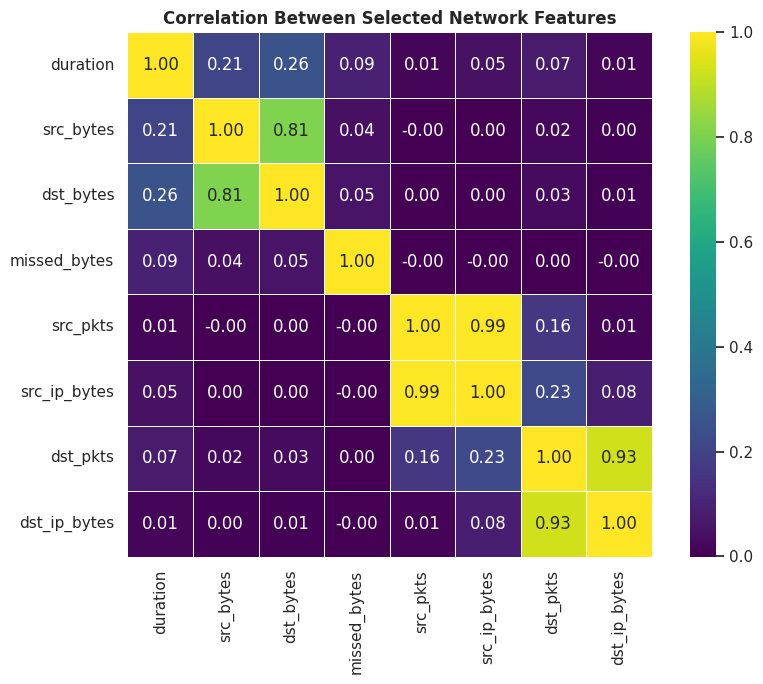

In [23]:
if len(numeric_eda) >= 2:

    corr_df = (
        eda_sample[numeric_eda]
        .apply(pd.to_numeric, errors="coerce")
        .corr()
    )

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        corr_df,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        square=True,
        linewidths=0.5
    )

    plt.title("Correlation Between Selected Network Features")

    # Heatmap labels are crowded, so use 90° only here.
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

## Phase 7 — Balanced Modeling Dataset

The complete dataset is used for initial EDA.  
For model development, an equal number of benign and attack samples is selected.

This avoids a dominant class overwhelming the proposed classifier and makes adversarial training practical on Colab.

In [24]:
parts = []

for label_value, group in df.groupby("label"):

    n = min(
        SAMPLE_PER_CLASS,
        len(group)
    )

    parts.append(
        group.sample(
            n=n,
            random_state=SEED
        )
    )

model_df = (
    pd.concat(parts, axis=0)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print("Modeling dataset:", model_df.shape)
print(model_df["label"].value_counts())

Modeling dataset: (143719, 46)
label
1    80000
0    63719
Name: count, dtype: int64


In [25]:
del df
del eda_sample
gc.collect()

print("Full dataframe released from memory.")

Full dataframe released from memory.


## Phase 8 — Duplicate Removal and Invalid Numeric Handling

In [26]:
before = len(model_df)

model_df = (
    model_df
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Duplicates removed:", before - len(model_df))
print("Remaining rows:", len(model_df))

Duplicates removed: 4488
Remaining rows: 139231


In [27]:
model_df = model_df.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Infinity values replaced with NaN.")

Infinity values replaced with NaN.


## Phase 9 — Feature Engineering

Raw IP addresses, URLs, DNS query strings, SSL subjects, and other high-identity text fields are excluded to reduce memorization and improve generalization.

The `type` field is also excluded because it directly reveals attack category information.

In [28]:
if "ts" in model_df.columns:

    timestamp = pd.to_datetime(
        pd.to_numeric(
            model_df["ts"],
            errors="coerce"
        ),
        unit="s",
        errors="coerce"
    )

    model_df["hour"] = timestamp.dt.hour
    model_df["day_of_week"] = timestamp.dt.dayofweek

In [29]:
log_features = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "missed_bytes",
    "src_pkts",
    "src_ip_bytes",
    "dst_pkts",
    "dst_ip_bytes",
    "http_request_body_len",
    "http_response_body_len"
]

for col in log_features:

    if col in model_df.columns:

        values = pd.to_numeric(
            model_df[col],
            errors="coerce"
        )

        model_df[col] = np.log1p(
            values.clip(lower=0)
        )

In [30]:
EXCLUDED_COLUMNS = {
    "label",
    "type",
    "ts",
    "src_ip",
    "dst_ip",
    "dns_query",
    "ssl_subject",
    "ssl_issuer",
    "http_uri",
    "http_referrer",
    "http_user_agent"
}

candidate_features = [
    c for c in model_df.columns
    if c not in EXCLUDED_COLUMNS
]

print("Candidate model features:", len(candidate_features))

Candidate model features: 37


## Phase 10 — Stratified Train / Validation / Test Split

In [31]:
train_df, temp_df = train_test_split(
    model_df,
    test_size=TEST_SIZE + VAL_SIZE,
    stratify=model_df["label"],
    random_state=SEED
)

relative_test_size = (
    TEST_SIZE /
    (TEST_SIZE + VAL_SIZE)
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (97461, 48)
Validation: (20885, 48)
Test: (20885, 48)


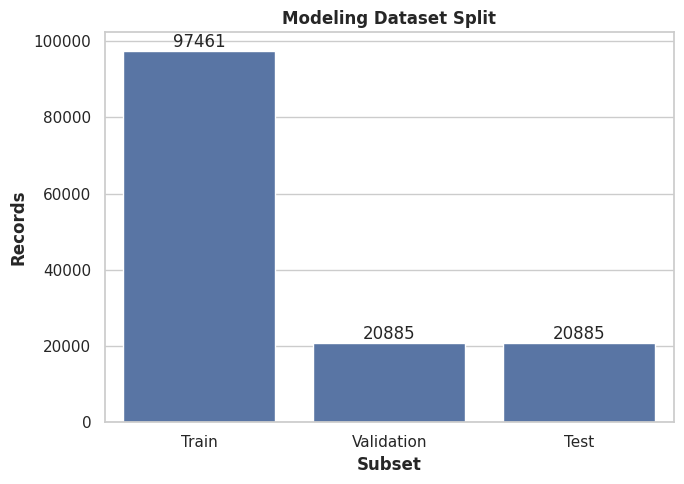

In [32]:
split_sizes = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Records": [
        len(train_df),
        len(val_df),
        len(test_df)
    ]
})

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=split_sizes,
    x="Dataset",
    y="Records"
)

ax.set_title("Modeling Dataset Split")
ax.set_xlabel("Subset")
ax.set_ylabel("Records")

plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## Phase 11 — Determine Numerical and Categorical Features

Columns that are numerically interpretable are converted to numeric form.  
Categorical columns with very high cardinality are excluded from the proposed model.

In [33]:
X_train_raw = train_df[candidate_features].copy()
X_val_raw = val_df[candidate_features].copy()
X_test_raw = test_df[candidate_features].copy()

y_train = train_df["label"].to_numpy(dtype=np.int64)
y_val = val_df["label"].to_numpy(dtype=np.int64)
y_test = test_df["label"].to_numpy(dtype=np.int64)

In [34]:
for col in X_train_raw.columns:

    converted = pd.to_numeric(
        X_train_raw[col],
        errors="coerce"
    )

    valid_fraction = converted.notna().mean()

    if valid_fraction >= 0.95:

        X_train_raw[col] = converted

        X_val_raw[col] = pd.to_numeric(
            X_val_raw[col],
            errors="coerce"
        )

        X_test_raw[col] = pd.to_numeric(
            X_test_raw[col],
            errors="coerce"
        )

In [35]:
numeric_cols = (
    X_train_raw
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_candidates = [
    c for c in X_train_raw.columns
    if c not in numeric_cols
]

categorical_cols = []
removed_high_cardinality = []

for col in categorical_candidates:

    cardinality = X_train_raw[col].nunique(
        dropna=True
    )

    if cardinality <= MAX_CATEGORY_CARDINALITY:
        categorical_cols.append(col)
    else:
        removed_high_cardinality.append(col)

print("Numerical features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))
print("High-cardinality removed:", removed_high_cardinality)

Numerical features: 18
Categorical features: 19
High-cardinality removed: []


In [36]:
feature_summary = pd.DataFrame({
    "Feature": numeric_cols + categorical_cols,
    "Type": (
        ["Numerical"] * len(numeric_cols)
        + ["Categorical"] * len(categorical_cols)
    )
})

display(feature_summary)

,Feature,Type
0,src_port,Numerical
1,dst_port,Numerical
2,duration,Numerical
3,src_bytes,Numerical
4,dst_bytes,Numerical
5,missed_bytes,Numerical
6,src_pkts,Numerical
7,src_ip_bytes,Numerical
8,dst_pkts,Numerical
9,dst_ip_bytes,Numerical


## Phase 12 — Training-Only Preprocessing

Following the proposed methodology:

### Numerical features
- Mean imputation
- Min-Max normalization to `[0, 1]`

### Categorical features
- Most-frequent imputation
- Ordinal encoding for embedding lookup

All transformations are fitted **only on training data** to prevent leakage.

In [37]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="mean")
    ),
    (
        "scaler",
        MinMaxScaler(
            feature_range=(0, 1),
            clip=True
        )
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            dtype=np.int64
        )
    )
])

In [38]:
if numeric_cols:

    X_train_num = numeric_pipeline.fit_transform(
        X_train_raw[numeric_cols]
    ).astype(np.float32)

    X_val_num = numeric_pipeline.transform(
        X_val_raw[numeric_cols]
    ).astype(np.float32)

    X_test_num = numeric_pipeline.transform(
        X_test_raw[numeric_cols]
    ).astype(np.float32)

else:

    X_train_num = np.empty(
        (len(train_df), 0),
        dtype=np.float32
    )

    X_val_num = np.empty(
        (len(val_df), 0),
        dtype=np.float32
    )

    X_test_num = np.empty(
        (len(test_df), 0),
        dtype=np.float32
    )

In [39]:
if categorical_cols:

    X_train_cat = categorical_pipeline.fit_transform(
        X_train_raw[categorical_cols]
    ).astype(np.int64)

    X_val_cat = categorical_pipeline.transform(
        X_val_raw[categorical_cols]
    ).astype(np.int64)

    X_test_cat = categorical_pipeline.transform(
        X_test_raw[categorical_cols]
    ).astype(np.int64)

    # unknown -1 -> 0; learned categories -> 1..N
    X_train_cat += 1
    X_val_cat += 1
    X_test_cat += 1

    encoder = categorical_pipeline.named_steps[
        "encoder"
    ]

    cat_cardinalities = [
        len(categories) + 1
        for categories in encoder.categories_
    ]

else:

    X_train_cat = np.empty(
        (len(train_df), 0),
        dtype=np.int64
    )

    X_val_cat = np.empty(
        (len(val_df), 0),
        dtype=np.int64
    )

    X_test_cat = np.empty(
        (len(test_df), 0),
        dtype=np.int64
    )

    cat_cardinalities = []

print("Numeric matrix:", X_train_num.shape)
print("Categorical matrix:", X_train_cat.shape)

Numeric matrix: (97461, 18)
Categorical matrix: (97461, 19)


## Phase 13 — PyTorch Dataset and DataLoaders

In [40]:
class NetworkTrafficDataset(Dataset):

    def __init__(
        self,
        numerical,
        categorical,
        labels
    ):

        self.numerical = torch.tensor(
            numerical,
            dtype=torch.float32
        )

        self.categorical = torch.tensor(
            categorical,
            dtype=torch.long
        )

        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            self.numerical[index],
            self.categorical[index],
            self.labels[index]
        )

In [41]:
train_dataset = NetworkTrafficDataset(
    X_train_num,
    X_train_cat,
    y_train
)

val_dataset = NetworkTrafficDataset(
    X_val_num,
    X_val_cat,
    y_val
)

test_dataset = NetworkTrafficDataset(
    X_test_num,
    X_test_cat,
    y_test
)

In [42]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("DataLoaders ready.")

DataLoaders ready.


# Phase 14 — Proposed Trust-Aware FT-Transformer

The proposed model contains:

- Numerical feature tokenization
- Categorical feature embeddings
- CLS token
- Trust score estimation
- Trust-weighted multi-head self-attention
- Residual connections
- Layer normalization
- Feed-forward network
- Binary classifier

The trust gate learns a value in `[0,1]` for each token.  
Low-trust feature representations contribute less strongly to attention Key/Value information.

In [43]:
class NumericalFeatureTokenizer(nn.Module):

    def __init__(
        self,
        n_features,
        d_token
    ):
        super().__init__()

        self.n_features = n_features
        self.d_token = d_token

        if n_features > 0:

            self.weight = nn.Parameter(
                torch.empty(
                    n_features,
                    d_token
                )
            )

            self.bias = nn.Parameter(
                torch.empty(
                    n_features,
                    d_token
                )
            )

            nn.init.xavier_uniform_(self.weight)
            nn.init.zeros_(self.bias)

    def forward(self, x):

        if self.n_features == 0:
            return x.new_empty(
                x.size(0),
                0,
                self.d_token
            )

        return (
            x.unsqueeze(-1)
            * self.weight.unsqueeze(0)
            + self.bias.unsqueeze(0)
        )

In [44]:
class CategoricalFeatureTokenizer(nn.Module):

    def __init__(
        self,
        cardinalities,
        d_token
    ):
        super().__init__()

        self.d_token = d_token

        self.embeddings = nn.ModuleList([
            nn.Embedding(
                cardinality,
                d_token
            )
            for cardinality in cardinalities
        ])

    def forward(self, x):

        if len(self.embeddings) == 0:
            return x.new_empty(
                x.size(0),
                0,
                self.d_token,
                dtype=torch.float32
            )

        tokens = [
            emb(x[:, index])
            for index, emb
            in enumerate(self.embeddings)
        ]

        return torch.stack(
            tokens,
            dim=1
        )

In [45]:
class TrustAwareTransformerBlock(nn.Module):

    def __init__(
        self,
        d_token,
        n_heads,
        dropout,
        ffn_factor=2
    ):
        super().__init__()

        hidden_trust = max(
            d_token // 2,
            8
        )

        self.trust_gate = nn.Sequential(
            nn.Linear(d_token, hidden_trust),
            nn.GELU(),
            nn.Linear(hidden_trust, 1),
            nn.Sigmoid()
        )

        self.attention = nn.MultiheadAttention(
            embed_dim=d_token,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(d_token)
        self.norm2 = nn.LayerNorm(d_token)

        hidden = d_token * ffn_factor

        self.ffn = nn.Sequential(
            nn.Linear(d_token, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_token)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        trust = self.trust_gate(x)

        trusted_context = x * trust

        attended, _ = self.attention(
            query=x,
            key=trusted_context,
            value=trusted_context,
            need_weights=False
        )

        x = self.norm1(
            x + self.dropout(attended)
        )

        transformed = self.ffn(x)

        x = self.norm2(
            x + self.dropout(transformed)
        )

        return x, trust.squeeze(-1)

In [46]:
class TrustAwareFTTransformer(nn.Module):

    def __init__(
        self,
        n_numeric,
        cat_cardinalities,
        d_token=64,
        n_heads=8,
        n_layers=4,
        dropout=0.15
    ):
        super().__init__()

        self.n_numeric = n_numeric

        self.numeric_tokenizer = (
            NumericalFeatureTokenizer(
                n_numeric,
                d_token
            )
        )

        self.categorical_tokenizer = (
            CategoricalFeatureTokenizer(
                cat_cardinalities,
                d_token
            )
        )

        n_features = (
            n_numeric
            + len(cat_cardinalities)
        )

        self.cls_token = nn.Parameter(
            torch.zeros(
                1,
                1,
                d_token
            )
        )

        self.position_embedding = nn.Parameter(
            torch.zeros(
                1,
                n_features + 1,
                d_token
            )
        )

        nn.init.normal_(
            self.cls_token,
            std=0.02
        )

        nn.init.normal_(
            self.position_embedding,
            std=0.02
        )

        self.blocks = nn.ModuleList([
            TrustAwareTransformerBlock(
                d_token=d_token,
                n_heads=n_heads,
                dropout=dropout,
                ffn_factor=FFN_FACTOR
            )
            for _ in range(n_layers)
        ])

        self.final_norm = nn.LayerNorm(
            d_token
        )

        self.classifier = nn.Sequential(
            nn.Linear(d_token, d_token),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_token, 2)
        )

    def forward(
        self,
        numerical,
        categorical,
        return_trust=False
    ):

        numeric_tokens = (
            self.numeric_tokenizer(
                numerical
            )
        )

        categorical_tokens = (
            self.categorical_tokenizer(
                categorical
            )
        )

        x = torch.cat(
            [
                numeric_tokens,
                categorical_tokens
            ],
            dim=1
        )

        cls = self.cls_token.expand(
            x.size(0),
            -1,
            -1
        )

        x = torch.cat(
            [cls, x],
            dim=1
        )

        x = (
            x
            + self.position_embedding[
                :, :x.size(1)
            ]
        )

        final_trust = None

        for block in self.blocks:
            x, final_trust = block(x)

        cls_representation = (
            self.final_norm(
                x[:, 0]
            )
        )

        logits = self.classifier(
            cls_representation
        )

        if return_trust:
            return logits, final_trust

        return logits

In [47]:
model = TrustAwareFTTransformer(
    n_numeric=len(numeric_cols),
    cat_cardinalities=cat_cardinalities,
    d_token=D_TOKEN,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

Trainable parameters: 158,470


## Phase 15 — Loss Function and Optimizer

In [48]:
class_counts_train = np.bincount(
    y_train,
    minlength=2
)

class_weights = (
    len(y_train)
    /
    (
        2.0
        * np.maximum(
            class_counts_train,
            1
        )
    )
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = (
    torch.optim.lr_scheduler
    .CosineAnnealingLR(
        optimizer,
        T_max=(
            CLEAN_EPOCHS
            + ADV_EPOCHS
        )
    )
)

print("Class weights:", class_weights)

Class weights: tensor([1.1734, 0.8712])


## Phase 16 — Prediction and Validation Threshold Utilities

In [49]:
def predict_loader(
    model,
    loader
):
    model.eval()

    y_true = []
    probabilities = []

    with torch.no_grad():

        for num, cat, y in loader:

            num = num.to(DEVICE)
            cat = cat.to(DEVICE)

            logits = model(
                num,
                cat
            )

            prob = torch.softmax(
                logits,
                dim=1
            )[:, 1]

            y_true.extend(
                y.numpy()
            )

            probabilities.extend(
                prob.cpu().numpy()
            )

    return (
        np.asarray(y_true),
        np.asarray(probabilities)
    )

In [50]:
def best_validation_threshold(
    y_true,
    probabilities
):
    thresholds = np.linspace(
        0.10,
        0.90,
        161
    )

    scores = []

    for threshold in thresholds:

        predictions = (
            probabilities
            >= threshold
        ).astype(int)

        scores.append(
            f1_score(
                y_true,
                predictions,
                zero_division=0
            )
        )

    index = int(
        np.argmax(scores)
    )

    return (
        float(thresholds[index]),
        float(scores[index])
    )

# Phase 17 — Initial Clean TAFT Training

# Phase 18 — FGSM Adversarial Sample Generation

FGSM perturbs only normalized numerical network features.  
Categorical feature indices remain unchanged.

In [55]:
def fgsm_attack(
    model,
    numerical,
    categorical,
    labels,
    epsilon=FGSM_EPS
):
    if numerical.size(1) == 0:
        return numerical.detach()

    x_adv = (
        numerical
        .detach()
        .clone()
        .requires_grad_(True)
    )

    logits = model(
        x_adv,
        categorical
    )

    loss = criterion(
        logits,
        labels
    )

    gradient = torch.autograd.grad(
        loss,
        x_adv,
        retain_graph=False,
        create_graph=False
    )[0]

    x_adv = (
        x_adv
        + epsilon
        * gradient.sign()
    )

    x_adv = torch.clamp(
        x_adv,
        0.0,
        1.0
    )

    return x_adv.detach()

# Phase 19 — PGD Adversarial Sample Generation

In [56]:
def pgd_attack(
    model,
    numerical,
    categorical,
    labels,
    epsilon=PGD_EPS,
    alpha=PGD_ALPHA,
    steps=PGD_STEPS
):
    if numerical.size(1) == 0:
        return numerical.detach()

    original = (
        numerical
        .detach()
        .clone()
    )

    x_adv = original.clone()

    x_adv = x_adv + (
        torch.empty_like(x_adv)
        .uniform_(
            -epsilon,
            epsilon
        )
    )

    x_adv = torch.clamp(
        x_adv,
        0.0,
        1.0
    )

    for _ in range(steps):

        x_adv.requires_grad_(True)

        logits = model(
            x_adv,
            categorical
        )

        loss = criterion(
            logits,
            labels
        )

        gradient = torch.autograd.grad(
            loss,
            x_adv,
            retain_graph=False,
            create_graph=False
        )[0]

        x_adv = (
            x_adv.detach()
            + alpha
            * gradient.sign()
        )

        perturbation = torch.clamp(
            x_adv - original,
            min=-epsilon,
            max=epsilon
        )

        x_adv = torch.clamp(
            original + perturbation,
            0.0,
            1.0
        ).detach()

    return x_adv

# Phase 20 — Adversarial Training

Each training batch is augmented with:

- clean records
- FGSM records
- PGD records

In [57]:
def train_adversarial_epoch(
    model,
    loader
):
    model.train()

    total_loss = 0.0
    total_samples = 0

    for num, cat, y in loader:

        num = num.to(DEVICE)
        cat = cat.to(DEVICE)
        y = y.to(DEVICE)

        model.eval()

        fgsm_num = fgsm_attack(
            model,
            num,
            cat,
            y
        )

        pgd_num = pgd_attack(
            model,
            num,
            cat,
            y
        )

        model.train()

        combined_num = torch.cat(
            [
                num,
                fgsm_num,
                pgd_num
            ],
            dim=0
        )

        combined_cat = torch.cat(
            [
                cat,
                cat,
                cat
            ],
            dim=0
        )

        combined_y = torch.cat(
            [
                y,
                y,
                y
            ],
            dim=0
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(
            combined_num,
            combined_cat
        )

        loss = criterion(
            logits,
            combined_y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += (
            loss.item()
            * len(combined_y)
        )

        total_samples += len(
            combined_y
        )

    return (
        total_loss
        / total_samples
    )

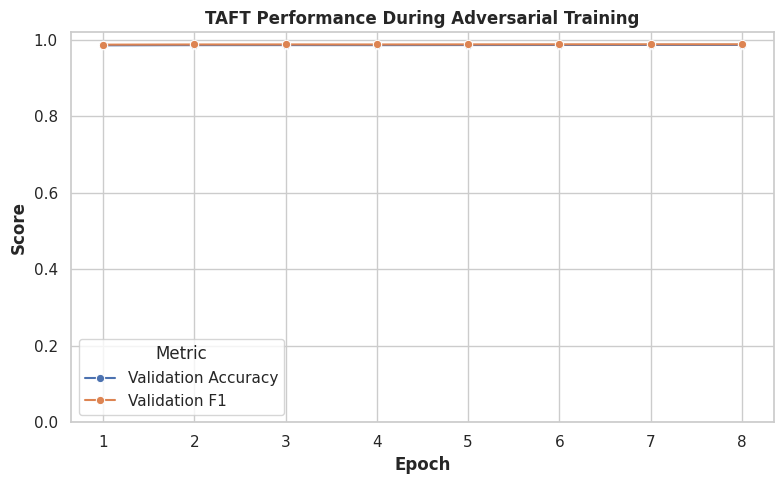

In [60]:
plt.figure(figsize=(8, 5))

plot_df = adv_history_df.melt(
    id_vars="Epoch",
    value_vars=[
        "Validation Accuracy",
        "Validation F1"
    ],
    var_name="Metric",
    value_name="Score"
)

sns.lineplot(
    data=plot_df,
    x="Epoch",
    y="Score",
    hue="Metric",
    marker="o"
)

plt.title(
    "TAFT Performance During Adversarial Training"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0, 1.02)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Phase 21 — Select Final Classification Threshold

The threshold is selected **only on validation data** and then fixed for final testing.

In [61]:
val_true, val_prob = predict_loader(
    model,
    val_loader
)

FINAL_THRESHOLD, validation_f1 = (
    best_validation_threshold(
        val_true,
        val_prob
    )
)

print(
    "Final threshold:",
    round(FINAL_THRESHOLD, 4)
)

print(
    "Validation F1:",
    round(validation_f1, 4)
)

Final threshold: 0.655
Validation F1: 0.9887


# Phase 22 — Final Clean / FGSM / PGD Evaluation

In [63]:
clean_result = evaluate_test_condition(
    model,
    test_loader,
    attack=None
)

fgsm_result = evaluate_test_condition(
    model,
    test_loader,
    attack="FGSM"
)

pgd_result = evaluate_test_condition(
    model,
    test_loader,
    attack="PGD"
)

results = {
    "Clean": clean_result,
    "FGSM": fgsm_result,
    "PGD": pgd_result
}

In [64]:
metrics_df = pd.DataFrame({
    name: result["metrics"]
    for name, result in results.items()
}).T

metrics_df.index.name = "Test Condition"

display(
    metrics_df.style.format(
        "{:.4f}"
    )
)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Test Condition,,,,,,
Clean,0.9884,0.9901,0.9896,0.9899,0.9980,0.9985
FGSM,0.9781,0.9819,0.9800,0.9809,0.9959,0.9966
PGD,0.9752,0.9814,0.9753,0.9783,0.9948,0.9954


## Phase 23 — Confusion Matrices

## Phase 25 — Precision-Recall Curves

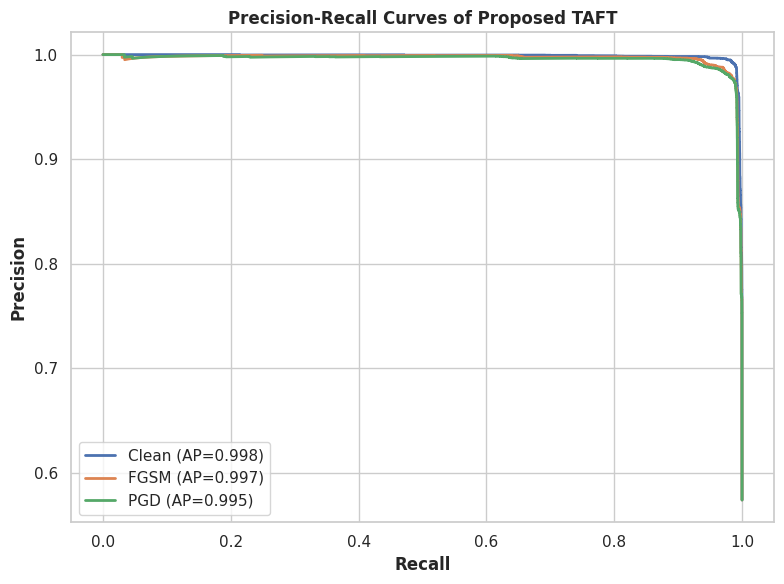

In [68]:
plt.figure(figsize=(8, 6))

for condition, result in results.items():

    precision, recall, _ = (
        precision_recall_curve(
            result["y_true"],
            result["probability"]
        )
    )

    ap = result[
        "metrics"
    ]["PR AUC"]

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=(
            f"{condition} "
            f"(AP={ap:.3f})"
        )
    )

plt.title(
    "Precision-Recall Curves of Proposed TAFT"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()

plt.tight_layout()
plt.show()

# Phase 26 — Calibration / Reliability Analysis

Expected Calibration Error (ECE) measures the agreement between prediction confidence and actual correctness.

In [69]:
def expected_calibration_error(
    y_true,
    probabilities,
    threshold,
    n_bins=10
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    confidence = np.where(
        predictions == 1,
        probabilities,
        1 - probabilities
    )

    correct = (
        predictions == y_true
    ).astype(float)

    bins = np.linspace(
        0,
        1,
        n_bins + 1
    )

    ece = 0.0
    rows = []

    for i in range(n_bins):

        lower = bins[i]
        upper = bins[i + 1]

        mask = (
            (confidence > lower)
            & (confidence <= upper)
        )

        if mask.sum() == 0:
            continue

        bin_accuracy = correct[
            mask
        ].mean()

        bin_confidence = confidence[
            mask
        ].mean()

        proportion = mask.mean()

        ece += (
            proportion
            * abs(
                bin_accuracy
                - bin_confidence
            )
        )

        rows.append({
            "Confidence": bin_confidence,
            "Observed Accuracy": bin_accuracy,
            "Samples": mask.sum()
        })

    return (
        float(ece),
        pd.DataFrame(rows)
    )

In [70]:
clean_ece, calibration_df = (
    expected_calibration_error(
        clean_result["y_true"],
        clean_result["probability"],
        FINAL_THRESHOLD
    )
)

print(
    "Expected Calibration Error:",
    round(clean_ece, 4)
)

display(calibration_df)

Expected Calibration Error: 0.0032


,Confidence,Observed Accuracy,Samples
0,0.366356,0.761905,21
1,0.450415,0.533333,30
2,0.563692,0.911765,34
3,0.668070,0.783133,83
4,0.752839,0.750000,156
5,0.859421,0.876652,227
6,0.994771,0.993312,20334


# Phase 27 — Trust-Aware Feature Analysis

In [72]:
def collect_feature_trust(
    model,
    loader,
    max_batches=50
):
    model.eval()

    trust_values = []

    with torch.no_grad():

        for batch_index, (
            num,
            cat,
            _
        ) in enumerate(loader):

            if batch_index >= max_batches:
                break

            num = num.to(DEVICE)
            cat = cat.to(DEVICE)

            _, trust = model(
                num,
                cat,
                return_trust=True
            )

            feature_trust = (
                trust[:, 1:]
                .cpu()
                .numpy()
            )

            trust_values.append(
                feature_trust
            )

    return np.concatenate(
        trust_values,
        axis=0
    )

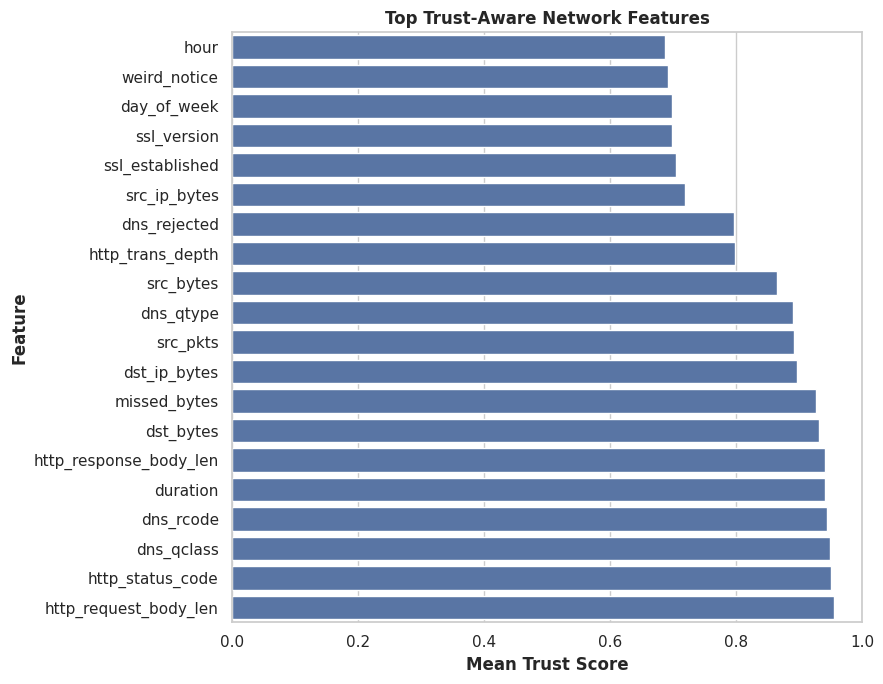

In [74]:
top_trust = (
    trust_df
    .head(20)
    .sort_values(
        "Mean Trust Score",
        ascending=True
    )
)

plt.figure(figsize=(9, 7))

sns.barplot(
    data=top_trust,
    x="Mean Trust Score",
    y="Feature",
    orient="h"
)

plt.title(
    "Top Trust-Aware Network Features"
)

plt.xlabel("Mean Trust Score")
plt.ylabel("Feature")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

# Phase 28 — Trustworthiness Assessment

The final proposed framework is assessed using:

- **Robustness**
- **Reliability**
- **Calibration**
- **Generalization**
- **Mean learned trust score**

In [75]:
train_true, train_prob = predict_loader(
    model,
    train_loader
)

train_pred = (
    train_prob
    >= FINAL_THRESHOLD
).astype(int)

train_accuracy = accuracy_score(
    train_true,
    train_pred
)

clean_accuracy = metrics_df.loc[
    "Clean",
    "Accuracy"
]

fgsm_accuracy = metrics_df.loc[
    "FGSM",
    "Accuracy"
]

pgd_accuracy = metrics_df.loc[
    "PGD",
    "Accuracy"
]

robustness_score = (
    min(
        fgsm_accuracy,
        pgd_accuracy
    )
    / max(
        clean_accuracy,
        1e-8
    )
)

reliability_score = np.mean([
    clean_accuracy,
    fgsm_accuracy,
    pgd_accuracy
])

generalization_gap = abs(
    train_accuracy
    - clean_accuracy
)

overall_trust_score = float(
    trust_matrix.mean()
)

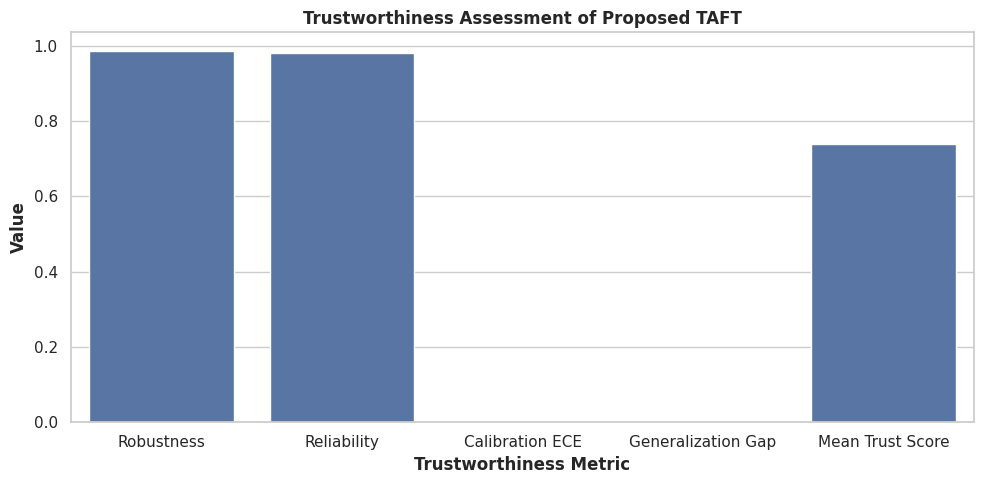

In [77]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=trustworthiness_df,
    x="Metric",
    y="Value"
)

ax.set_title(
    "Trustworthiness Assessment of Proposed TAFT"
)

ax.set_xlabel("Trustworthiness Metric")
ax.set_ylabel("Value")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Phase 29 — SHAP Explainability

A small test subset is used because model-agnostic SHAP can be computationally expensive for deep neural networks.

This phase produces:

- global SHAP feature importance
- SHAP beeswarm summary
- local waterfall explanation

In [78]:
import shap

SHAP_BACKGROUND = 60
SHAP_EXPLAIN_SAMPLES = 40

In [79]:
processed_test = np.hstack([
    X_test_num.astype(np.float32),
    X_test_cat.astype(np.float32)
])

processed_feature_names = (
    numeric_cols
    + categorical_cols
)

n_numeric = len(
    numeric_cols
)

In [80]:
def shap_prediction_function(x):

    x = np.asarray(
        x,
        dtype=np.float32
    )

    numeric = x[
        :, :n_numeric
    ]

    categorical = x[
        :, n_numeric:
    ]

    if categorical.shape[1] > 0:

        categorical = np.rint(
            categorical
        ).astype(np.int64)

        for index, cardinality in enumerate(
            cat_cardinalities
        ):

            categorical[:, index] = np.clip(
                categorical[:, index],
                0,
                cardinality - 1
            )

    num_tensor = torch.tensor(
        numeric,
        dtype=torch.float32,
        device=DEVICE
    )

    cat_tensor = torch.tensor(
        categorical,
        dtype=torch.long,
        device=DEVICE
    )

    model.eval()

    with torch.no_grad():

        logits = model(
            num_tensor,
            cat_tensor
        )

        probability = torch.softmax(
            logits,
            dim=1
        )[:, 1]

    return probability.cpu().numpy()

In [81]:
rng = np.random.default_rng(
    SEED
)

background_indices = rng.choice(
    len(processed_test),
    size=min(
        SHAP_BACKGROUND,
        len(processed_test)
    ),
    replace=False
)

explain_indices = rng.choice(
    len(processed_test),
    size=min(
        SHAP_EXPLAIN_SAMPLES,
        len(processed_test)
    ),
    replace=False
)

background = processed_test[
    background_indices
]

X_explain = processed_test[
    explain_indices
]

In [82]:
explainer = shap.Explainer(
    shap_prediction_function,
    background,
    algorithm="permutation",
    feature_names=processed_feature_names
)

shap_values = explainer(
    X_explain,
    max_evals=max(
        2 * len(
            processed_feature_names
        ) + 1,
        100
    )
)

print(
    "SHAP values shape:",
    shap_values.values.shape
)

PermutationExplainer explainer: 41it [01:19,  2.14s/it]

SHAP values shape: (40, 37)


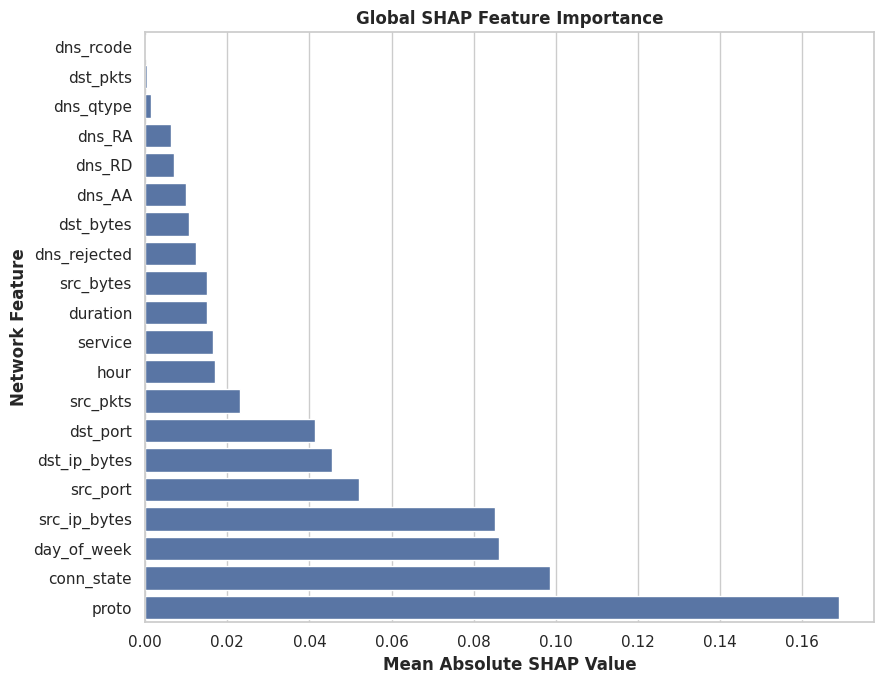

In [84]:
top_shap = (
    global_shap
    .head(20)
    .sort_values(
        "Mean Absolute SHAP",
        ascending=True
    )
)

plt.figure(figsize=(9, 7))

sns.barplot(
    data=top_shap,
    x="Mean Absolute SHAP",
    y="Feature",
    orient="h"
)

plt.title(
    "Global SHAP Feature Importance"
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel("Network Feature")

plt.tight_layout()
plt.show()

# Phase 32 — Save Model, Preprocessing, and Results

In [89]:
OUTPUT_DIR = PROJECT_DIR / "TAFT_Outputs"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Output folder:", OUTPUT_DIR)

Output folder: /content/drive/MyDrive/TAFT_Project/TAFT_Outputs


In [90]:
torch.save(
    {
        "model_state_dict":
            model.state_dict(),

        "n_numeric":
            len(numeric_cols),

        "categorical_cardinalities":
            cat_cardinalities,

        "numeric_features":
            numeric_cols,

        "categorical_features":
            categorical_cols,

        "threshold":
            FINAL_THRESHOLD,

        "d_token":
            D_TOKEN,

        "n_heads":
            N_HEADS,

        "n_layers":
            N_LAYERS
    },
    OUTPUT_DIR
    / "taft_ton_iot_model.pt"
)

In [91]:
joblib.dump(
    {
        "numeric_pipeline":
            numeric_pipeline,

        "categorical_pipeline":
            categorical_pipeline,

        "numeric_features":
            numeric_cols,

        "categorical_features":
            categorical_cols
    },
    OUTPUT_DIR
    / "taft_preprocessing.joblib"
)

['/content/drive/MyDrive/TAFT_Project/TAFT_Outputs/taft_preprocessing.joblib']

In [92]:
metrics_df.to_csv(
    OUTPUT_DIR
    / "taft_test_metrics.csv"
)

trustworthiness_df.to_csv(
    OUTPUT_DIR
    / "taft_trustworthiness_metrics.csv",
    index=False
)

trust_df.to_csv(
    OUTPUT_DIR
    / "taft_feature_trust_scores.csv",
    index=False
)

global_shap.to_csv(
    OUTPUT_DIR
    / "taft_shap_feature_importance.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.
